# Validate US City Filtered Data

This notebook validates the filtered US foot traffic data for the 6 study cities:
- **Transit-oriented**: New York, Chicago, Washington DC
- **Car-dependent**: Houston, Atlanta, Phoenix

Data source: `dbs/us_foot_traffic/cities/{city}/part_*.parquet`

In [1]:
%cd /workspace

/workspace


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
from pathlib import Path

CITIES_DIR = Path("dbs/us_foot_traffic/cities")

CITIES = ['new_york', 'chicago', 'washington_dc', 'houston', 'atlanta', 'phoenix']
CITY_TYPES = {
    'new_york': 'transit', 'chicago': 'transit', 'washington_dc': 'transit',
    'houston': 'car', 'atlanta': 'car', 'phoenix': 'car'
}

## 1. Load City Statistics Summary

In [20]:
# Load pre-computed statistics
stats_df = pd.read_csv(CITIES_DIR / 'city_statistics.csv')
stats_df

,city,msa_code,msa_name,city_type,total_records,unique_pois,total_visits,weeks,date_start,date_end,cbgs_coverage_pct,unified_category_coverage_pct
0,new_york,35620,"New York-Newark-Jersey City, NY-NJ-PA",transit,14139105,290270,31931487071,53,2024-01-01 00:00:00+00:00,2025-01-05 00:00:00+00:00,76.0,84.3
1,chicago,16980,"Chicago-Naperville-Elgin, IL-IN-WI",transit,6778153,140675,12641873838,53,2024-01-01 00:00:00+00:00,2025-01-05 00:00:00+00:00,75.9,83.5
2,washington_dc,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",transit,3968600,84650,5312196282,53,2024-01-01 00:00:00+00:00,2025-01-05 00:00:00+00:00,70.8,80.9
3,houston,26420,"Houston-The Woodlands-Sugar Land, TX",car,5854566,120735,15625437553,53,2024-01-01 00:00:00+00:00,2025-01-05 00:00:00+00:00,75.3,83.4
4,atlanta,12060,"Atlanta-Sandy Springs-Alpharetta, GA",car,4781605,102181,10852073303,53,2024-01-01 00:00:00+00:00,2025-01-05 00:00:00+00:00,72.9,82.6
5,phoenix,38060,"Phoenix-Mesa-Chandler, AZ",car,3789098,80728,7469064058,53,2024-01-01 00:00:00+00:00,2025-01-05 00:00:00+00:00,74.0,80.7


In [11]:
# Summary stats
print(f"Total POI-week records: {stats_df['total_records'].sum():,}")
print(f"Total visits: {stats_df['total_visits'].sum():,}")
print(f"Total unique POIs: {stats_df['unique_pois'].sum():,}")
print(f"\nDate range: {stats_df['date_start'].min()} to {stats_df['date_end'].max()}")
print(f"Weeks covered: {stats_df['weeks'].iloc[0]}")

Total POI-week records: 39,311,127
Total visits: 83,832,132,105
Total unique POIs: 819,239

Date range: 2024-01-01 00:00:00+00:00 to 2025-01-05 00:00:00+00:00
Weeks covered: 53


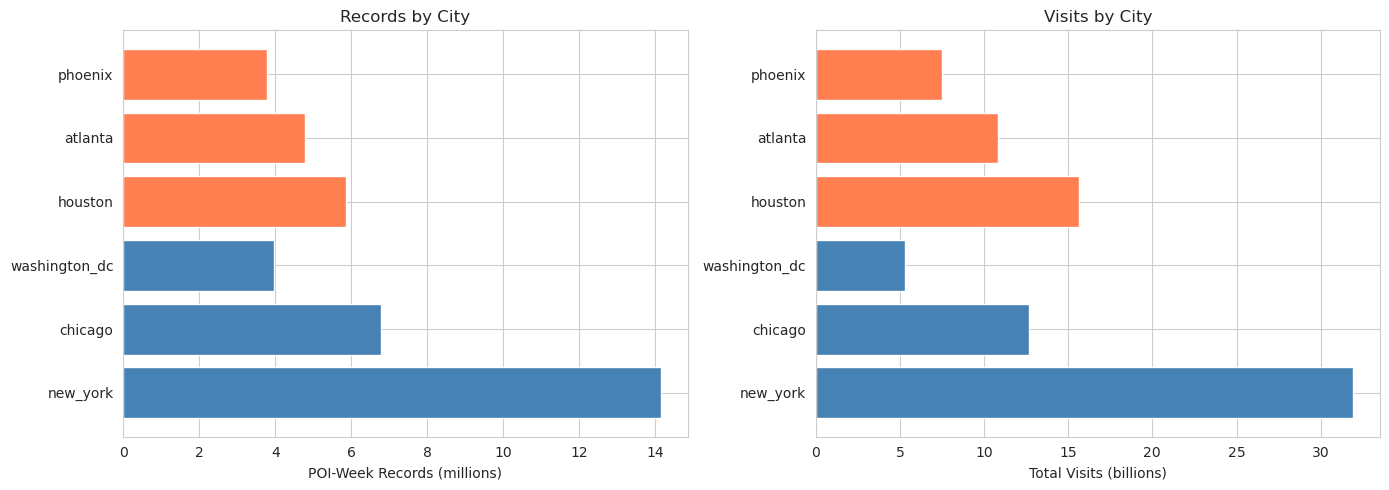

Blue = Transit-oriented, Orange = Car-dependent


In [12]:
# Visualize records by city
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue' if CITY_TYPES[c] == 'transit' else 'coral' for c in stats_df['city']]

# Records
axes[0].barh(stats_df['city'], stats_df['total_records'] / 1e6, color=colors)
axes[0].set_xlabel('POI-Week Records (millions)')
axes[0].set_title('Records by City')

# Visits
axes[1].barh(stats_df['city'], stats_df['total_visits'] / 1e9, color=colors)
axes[1].set_xlabel('Total Visits (billions)')
axes[1].set_title('Visits by City')

plt.tight_layout()
plt.show()

print("Blue = Transit-oriented, Orange = Car-dependent")

## 2. Data Quality Checks

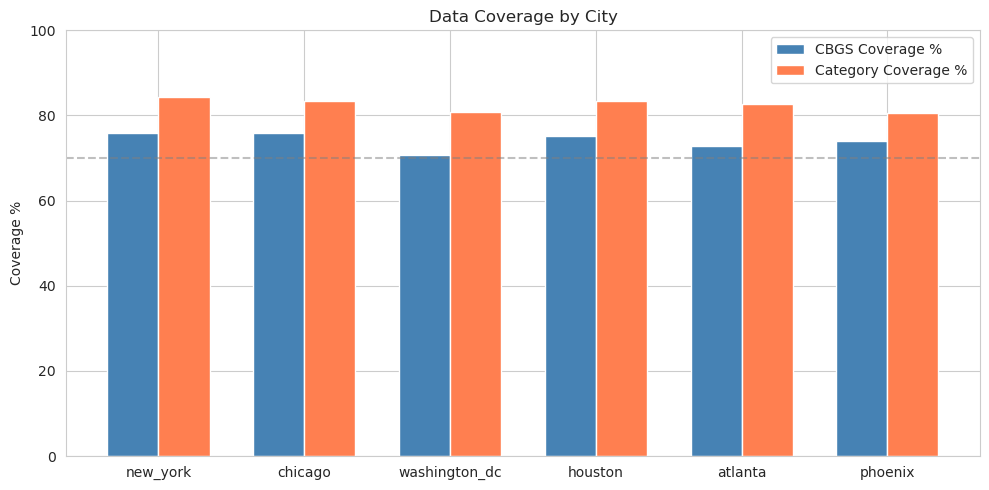

In [13]:
# Coverage metrics
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(stats_df))
width = 0.35

ax.bar(x - width/2, stats_df['cbgs_coverage_pct'], width, label='CBGS Coverage %', color='steelblue')
ax.bar(x + width/2, stats_df['unified_category_coverage_pct'], width, label='Category Coverage %', color='coral')

ax.set_ylabel('Coverage %')
ax.set_xticks(x)
ax.set_xticklabels(stats_df['city'])
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5)

plt.title('Data Coverage by City')
plt.tight_layout()
plt.show()

## 3. Load Sample Data from Each City

In [22]:
def load_city_sample(city_name, n_files=1):
    """Load sample data from a city."""
    city_dir = CITIES_DIR / city_name
    part_files = sorted(city_dir.glob('part_*.parquet'))[:n_files]
    return pd.concat([pd.read_parquet(f) for f in part_files], ignore_index=True)

# Load one sample file from New York
df_sample = load_city_sample('new_york', n_files=1)
print(f"Sample size: {len(df_sample):,} records")
df_sample.head()

Sample size: 411,965 records


,POI_CBG,SUB_CATEGORY,VISITOR_HOME_CBGS,ID_STORE,VISIT_COUNTS,DATE_RANGE_START,DATE_RANGE_END,study_city,unified_category
0,360050418001,Electronics Stores,"{""360050414004"":59,""360050418002"":58,""36005044...",8312554,234,2024-01-01 00:00:00+00:00,2024-01-07 00:00:00+00:00,new_york,retail_specialty
1,360610072004,Snack and Nonalcoholic Beverage Bars,"{""360610072004"":226,""360610068001"":66,""3608501...",5647607,468,2024-01-01 00:00:00+00:00,2024-01-07 00:00:00+00:00,new_york,food_dining
2,360810267003,"Gift, Novelty, and Souvenir Stores","{""360810267003"":171,""360810383021"":58,""3608102...",8364999,743,2024-01-01 00:00:00+00:00,2024-01-07 00:00:00+00:00,new_york,NaN
3,360470033001,Full-Service Restaurants,"{""360470193004"":749,""360470265001"":376,""360470...",8744241,1528,2024-01-01 00:00:00+00:00,2024-01-07 00:00:00+00:00,new_york,food_dining
4,360610139003,"Colleges, Universities, and Professional Schools","{""360610139003"":643,""360610015022"":169,""360594...",5684863,2421,2024-01-01 00:00:00+00:00,2024-01-07 00:00:00+00:00,new_york,education_higher


In [23]:
# Schema
print("Columns:")
for col in df_sample.columns:
    print(f"  {col}: {df_sample[col].dtype}")

Columns:
  POI_CBG: str
  SUB_CATEGORY: string
  VISITOR_HOME_CBGS: str
  ID_STORE: str
  VISIT_COUNTS: object
  DATE_RANGE_START: datetime64[ms, UTC]
  DATE_RANGE_END: datetime64[ms, UTC]
  study_city: str
  unified_category: str


## 4. VISITOR_HOME_CBGS Validation

In [24]:
def parse_cbgs(cbgs_str):
    """Parse VISITOR_HOME_CBGS JSON string."""
    if pd.isna(cbgs_str) or cbgs_str == '' or cbgs_str == '{}':
        return {}
    try:
        return json.loads(cbgs_str)
    except:
        return {}

# Analyze CBGS distribution
cbgs_sample = df_sample['VISITOR_HOME_CBGS'].apply(parse_cbgs)
cbgs_counts = cbgs_sample.apply(len)

print("VISITOR_HOME_CBGS Statistics:")
print(f"  Records with valid CBGS: {(cbgs_counts > 0).sum():,} ({(cbgs_counts > 0).mean()*100:.1f}%)")
print(f"  Mean origin tracts per POI-week: {cbgs_counts[cbgs_counts > 0].mean():.1f}")
print(f"  Median origin tracts per POI-week: {cbgs_counts[cbgs_counts > 0].median():.0f}")
print(f"  Max origin tracts: {cbgs_counts.max()}")

VISITOR_HOME_CBGS Statistics:
  Records with valid CBGS: 324,571 (78.8%)
  Mean origin tracts per POI-week: 19.1
  Median origin tracts per POI-week: 5
  Max origin tracts: 1000


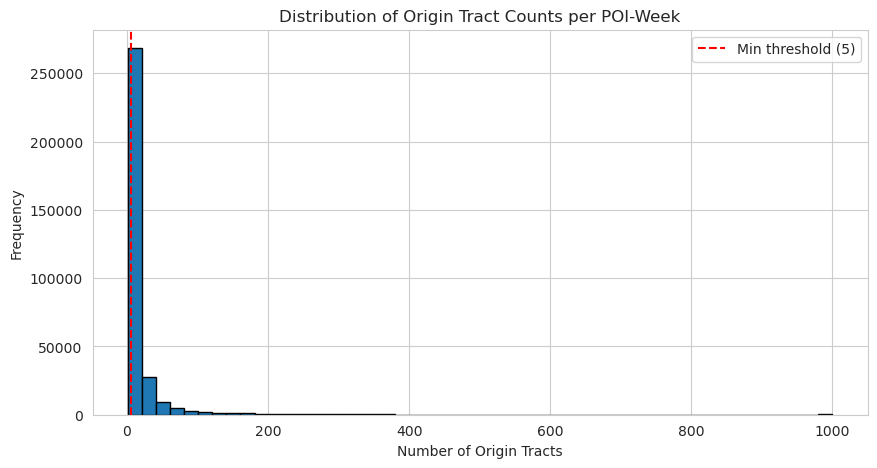


Records with >= 5 origin tracts: 163,185 (39.6%)


In [25]:
# Distribution of origin tract counts
fig, ax = plt.subplots(figsize=(10, 5))
cbgs_counts[cbgs_counts > 0].hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('Number of Origin Tracts')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Origin Tract Counts per POI-Week')
ax.axvline(x=5, color='red', linestyle='--', label='Min threshold (5)')
ax.legend()
plt.show()

print(f"\nRecords with >= 5 origin tracts: {(cbgs_counts >= 5).sum():,} ({(cbgs_counts >= 5).mean()*100:.1f}%)")

## 5. Unified Category Distribution

In [32]:
# Load larger sample for category analysis
df_cats = load_city_sample('new_york', n_files=3)

cat_dist = df_cats.groupby('unified_category').agg(
    records=('unified_category', 'count'),
    visits=('VISIT_COUNTS', 'sum'),
    pois=('ID_STORE', 'nunique')
).sort_values('visits', ascending=False)

cat_dist['visit_pct'] = (cat_dist['visits'] / cat_dist['visits'].sum() * 100).round(1)
cat_dist

,records,visits,pois,visit_pct
unified_category,,,,
entertainment_recreation,65815,392561638,13857,20.7
food_dining,382133,369040530,80627,19.4
automotive,138724,299708532,30087,15.8
retail_specialty,181822,250551190,38862,13.2
professional_services,37677,214179773,8057,11.3
personal_services,83816,90926840,19098,4.8
accommodation_travel,37512,80488362,7987,4.2
financial_services,68670,68541645,14745,3.6
education_higher,7060,51231784,1496,2.7


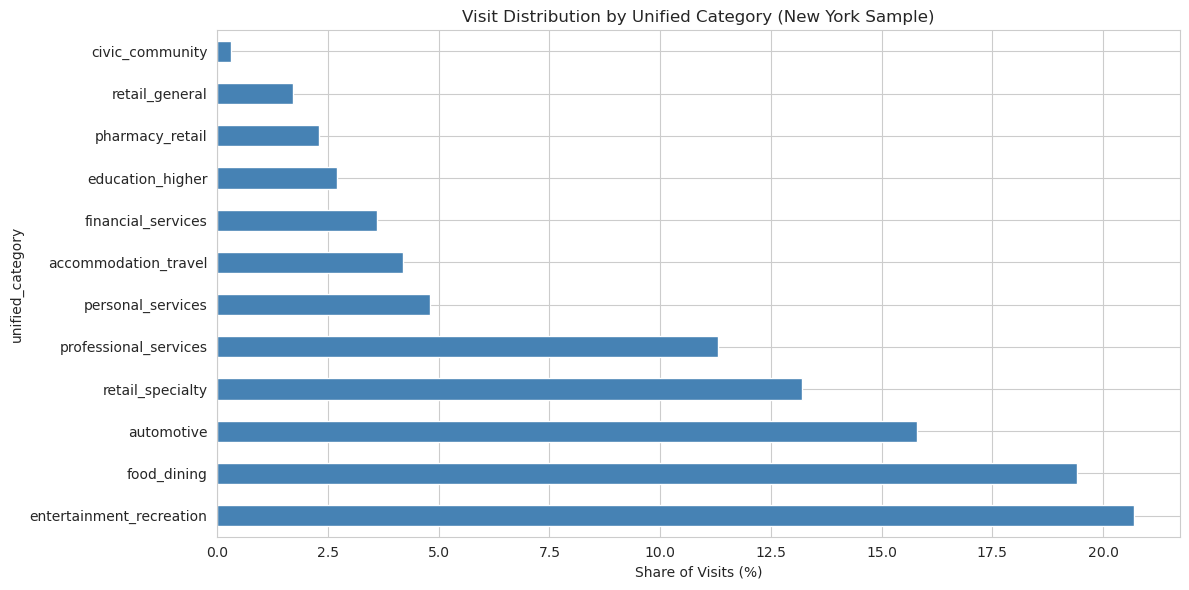

In [33]:
# Visualize category distribution
fig, ax = plt.subplots(figsize=(12, 6))
cat_dist['visit_pct'] = pd.to_numeric(cat_dist['visit_pct'], errors='coerce')
cat_dist['visit_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Share of Visits (%)')
ax.set_title('Visit Distribution by Unified Category (New York Sample)')
plt.tight_layout()
plt.show()

## 6. Temporal Coverage

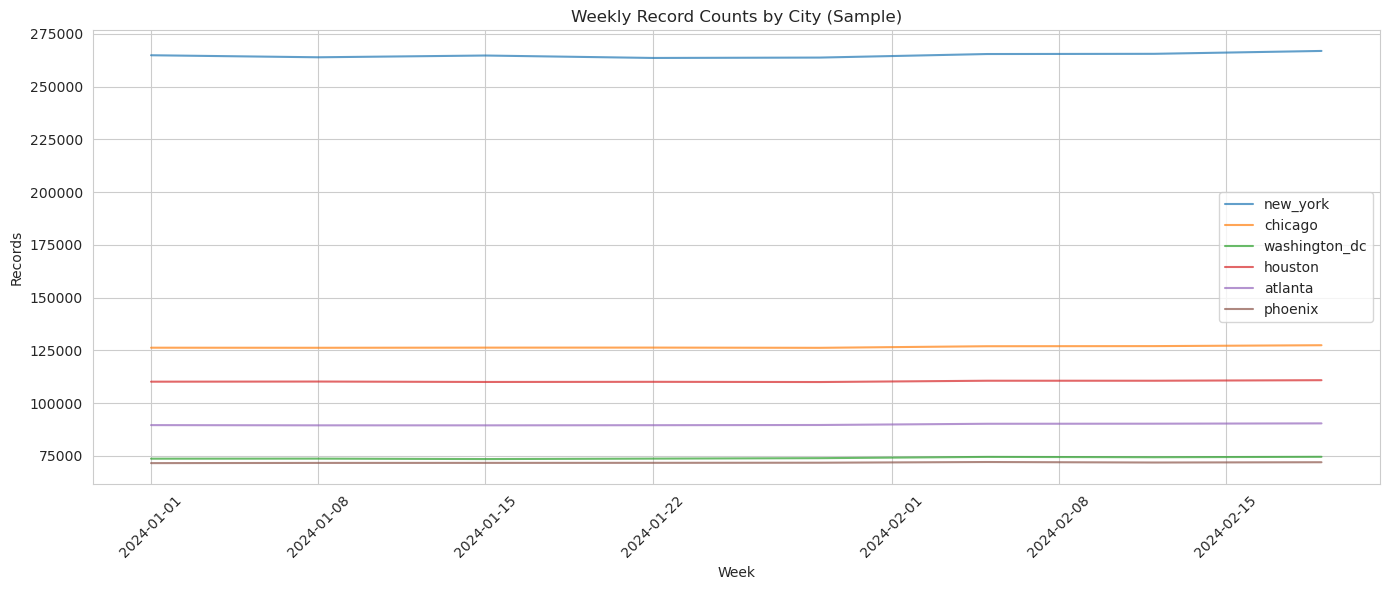

In [34]:
# Check weekly coverage across all cities
weekly_counts = {}

for city in CITIES:
    city_dir = CITIES_DIR / city
    # Load first few files to get date distribution
    part_files = sorted(city_dir.glob('part_*.parquet'))[:5]
    if part_files:
        df_temp = pd.concat([pd.read_parquet(f, columns=['DATE_RANGE_START']) for f in part_files])
        weekly_counts[city] = df_temp['DATE_RANGE_START'].value_counts().sort_index()

# Plot temporal coverage
fig, ax = plt.subplots(figsize=(14, 6))

for city, counts in weekly_counts.items():
    color = 'steelblue' if CITY_TYPES[city] == 'transit' else 'coral'
    ax.plot(counts.index, counts.values, label=city, alpha=0.7)

ax.set_xlabel('Week')
ax.set_ylabel('Records')
ax.set_title('Weekly Record Counts by City (Sample)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Geographic Validation

In [35]:
# Check POI_CBG county distribution to verify filtering
df_sample['county_fips'] = df_sample['POI_CBG'].astype(str).str.zfill(12).str[:5]

county_dist = df_sample.groupby('county_fips').agg(
    records=('county_fips', 'count'),
    pois=('ID_STORE', 'nunique')
).sort_values('records', ascending=False)

print(f"Counties in New York sample: {len(county_dist)}")
county_dist.head(10)

Counties in New York sample: 23


,records,pois
county_fips,,
36061,57092,36689
36047,45457,29273
36081,39001,25226
36103,37396,24568
36059,33369,21560
34003,22148,14380
36119,21772,14130
36005,20302,13086
34023,16189,10462


In [36]:
# Verify all counties are in the expected MSA
NY_COUNTIES = [
    '36005', '36047', '36061', '36081', '36085', '36059', '36103',
    '36119', '36087', '36079', '34003', '34013', '34017', '34019',
    '34023', '34025', '34027', '34029', '34031', '34035', '34037',
    '34039', '42103',
]

unexpected = set(county_dist.index) - set(NY_COUNTIES)
if unexpected:
    print(f"WARNING: Unexpected counties found: {unexpected}")
else:
    print("✓ All counties are within the expected New York MSA definition")

✓ All counties are within the expected New York MSA definition


## 8. Cross-City Comparison

In [37]:
# Compare key metrics across cities
stats_df['visits_per_poi'] = stats_df['total_visits'] / stats_df['unique_pois']
stats_df['records_per_poi'] = stats_df['total_records'] / stats_df['unique_pois']

comparison = stats_df[['city', 'city_type', 'unique_pois', 'visits_per_poi', 'records_per_poi', 
                       'cbgs_coverage_pct', 'unified_category_coverage_pct']].copy()
comparison['visits_per_poi'] = comparison['visits_per_poi'].round(0).astype(int)
comparison['records_per_poi'] = comparison['records_per_poi'].round(1)
comparison

,city,city_type,unique_pois,visits_per_poi,records_per_poi,cbgs_coverage_pct,unified_category_coverage_pct
0,new_york,transit,290270,110006,48.7,76.0,84.3
1,chicago,transit,140675,89866,48.2,75.9,83.5
2,washington_dc,transit,84650,62755,46.9,70.8,80.9
3,houston,car,120735,129419,48.5,75.3,83.4
4,atlanta,car,102181,106204,46.8,72.9,82.6
5,phoenix,car,80728,92521,46.9,74.0,80.7


In [38]:
# Compare transit vs car cities
transit_cities = stats_df[stats_df['city_type'] == 'transit']
car_cities = stats_df[stats_df['city_type'] == 'car']

print("Transit-oriented cities:")
print(f"  Total POIs: {transit_cities['unique_pois'].sum():,}")
print(f"  Total visits: {transit_cities['total_visits'].sum():,}")
print(f"  Avg CBGS coverage: {transit_cities['cbgs_coverage_pct'].mean():.1f}%")

print("\nCar-dependent cities:")
print(f"  Total POIs: {car_cities['unique_pois'].sum():,}")
print(f"  Total visits: {car_cities['total_visits'].sum():,}")
print(f"  Avg CBGS coverage: {car_cities['cbgs_coverage_pct'].mean():.1f}%")

Transit-oriented cities:
  Total POIs: 515,595
  Total visits: 49,885,557,191
  Avg CBGS coverage: 74.2%

Car-dependent cities:
  Total POIs: 303,644
  Total visits: 33,946,574,914
  Avg CBGS coverage: 74.1%


## 9. Data Quality Summary

In [39]:
print("=" * 60)
print("US CITY DATA VALIDATION SUMMARY")
print("=" * 60)

print(f"""
OVERALL STATISTICS:
  Cities: {len(stats_df)}
  Total POI-week records: {stats_df['total_records'].sum():,}
  Total visits: {stats_df['total_visits'].sum():,}
  Total unique POIs: {stats_df['unique_pois'].sum():,}
  
TEMPORAL COVERAGE:
  Date range: {stats_df['date_start'].min()[:10]} to {stats_df['date_end'].max()[:10]}
  Weeks: {stats_df['weeks'].iloc[0]}
  
DATA QUALITY:
  CBGS coverage: {stats_df['cbgs_coverage_pct'].min():.1f}% - {stats_df['cbgs_coverage_pct'].max():.1f}%
  Category coverage: {stats_df['unified_category_coverage_pct'].min():.1f}% - {stats_df['unified_category_coverage_pct'].max():.1f}%
  
BY CITY TYPE:
  Transit (NY, Chicago, DC): {transit_cities['total_records'].sum():,} records, {transit_cities['unique_pois'].sum():,} POIs
  Car (Houston, Atlanta, Phoenix): {car_cities['total_records'].sum():,} records, {car_cities['unique_pois'].sum():,} POIs
""")

# Validation checks
checks = [
    ("All 6 cities present", len(stats_df) == 6),
    ("53 weeks coverage", (stats_df['weeks'] == 53).all()),
    ("CBGS coverage > 70%", (stats_df['cbgs_coverage_pct'] >= 70).all()),
    ("Category coverage > 80%", (stats_df['unified_category_coverage_pct'] >= 80).all()),
    ("All cities have data", (stats_df['total_records'] > 0).all()),
]

print("VALIDATION CHECKS:")
for check_name, passed in checks:
    status = "✓" if passed else "✗"
    print(f"  {status} {check_name}")

US CITY DATA VALIDATION SUMMARY

OVERALL STATISTICS:
  Cities: 6
  Total POI-week records: 39,311,127
  Total visits: 83,832,132,105
  Total unique POIs: 819,239

TEMPORAL COVERAGE:
  Date range: 2024-01-01 to 2025-01-05
  Weeks: 53

DATA QUALITY:
  CBGS coverage: 70.8% - 76.0%
  Category coverage: 80.7% - 84.3%

BY CITY TYPE:
  Transit (NY, Chicago, DC): 24,885,858 records, 515,595 POIs
  Car (Houston, Atlanta, Phoenix): 14,425,269 records, 303,644 POIs

VALIDATION CHECKS:
  ✓ All 6 cities present
  ✓ 53 weeks coverage
  ✓ CBGS coverage > 70%
  ✓ Category coverage > 80%
  ✓ All cities have data


## 10. File Size Summary

In [40]:
# File sizes per city
for city in CITIES:
    city_dir = CITIES_DIR / city
    part_files = list(city_dir.glob('part_*.parquet'))
    total_size = sum(f.stat().st_size for f in part_files) / 1e9
    print(f"{city}: {len(part_files)} files, {total_size:.2f} GB")

# Total size
all_files = list(CITIES_DIR.glob('*/part_*.parquet'))
total_size = sum(f.stat().st_size for f in all_files) / 1e9
print(f"\nTotal: {len(all_files)} files, {total_size:.2f} GB")

new_york: 35 files, 1.89 GB
chicago: 35 files, 0.83 GB
washington_dc: 35 files, 0.39 GB
houston: 35 files, 0.87 GB
atlanta: 35 files, 0.67 GB
phoenix: 35 files, 0.49 GB

Total: 210 files, 5.14 GB
